Decision Tree (Before SMOTE):
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1577
           1       0.48      0.52      0.50       423

    accuracy                           0.78      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.79      0.78      0.78      2000

Logistic Regression (Before SMOTE):
              precision    recall  f1-score   support

           0       0.79      0.96      0.87      1577
           1       0.24      0.05      0.08       423

    accuracy                           0.77      2000
   macro avg       0.52      0.50      0.47      2000
weighted avg       0.67      0.77      0.70      2000

Decision Tree (After SMOTE):
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1577
           1       0.43      0.63      0.51       423

    accuracy                           0.74      2000
   macro avg       0.66      0.70

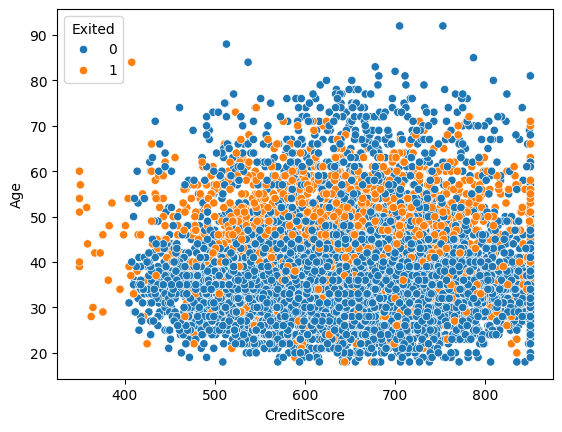

In [ ]:
# 1. Import libraries
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# 2. Load data
df = pd.read_csv('Churn_Modelling.csv')

# 3. Quick visualization (before SMOTE)
sns.scatterplot(data=df, x='CreditScore', y='Age', hue='Exited')

# 4. Encode categorical columns
for col in df.select_dtypes(include='object'):
    df[col] = LabelEncoder().fit_transform(df[col])

# 5. Split data
X = df.drop('Exited', axis=1)
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# 6. WITHOUT SMOTE

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
print("Decision Tree (Before SMOTE):")
print(classification_report(y_test, dt.predict(X_test)))

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("Logistic Regression (Before SMOTE):")
print(classification_report(y_test, lr.predict(X_test)))

# 7. APPLY SMOTE

smote = SMOTE(random_state=101)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# -----------------------
# 8. WITH SMOTE
# -----------------------

# Decision Tree
dt.fit(X_train_sm, y_train_sm)
print("Decision Tree (After SMOTE):")
print(classification_report(y_test, dt.predict(X_test)))

# Logistic Regression
lr.fit(X_train_sm, y_train_sm)
print("Logistic Regression (After SMOTE):")
print(classification_report(y_test, lr.predict(X_test)))